<a href="https://colab.research.google.com/github/hwasun-zip/Behind-the-Coupon/blob/main/notebooks/02_structure_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# 작업 환경 복구
from google.colab import drive
drive.mount('/content/drive')

!pip install -q koreanize-matplotlib
import os, sys
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import koreanize_matplotlib
plt.rcParams['axes.unicode_minus'] = False

BASE = '/content/drive/MyDrive/Behind-the-Coupon'
sys.path.append(f'{BASE}/src')
from els_engine import *          # 01에서 저장한 엔진 불러오기

raw = pd.read_csv(f'{BASE}/data/index_close.csv', index_col=0, parse_dates=True)
px = raw.sort_index().ffill()
print(px.shape, px.index.min().date(), '~', px.index.max().date())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(5921, 5) 2004-01-02 ~ 2026-10-02


In [18]:
# 분석 설정과 확장 지표
COUPON = 0.06                  # 비교용 가정 쿠폰
RF = 0.03                      # 무위험 금리 (임시)
COMMON_START = '2007-03-30'    # 모든 조합을 같은 기간으로 비교
STRUCT = dict(strikes=(0.90, 0.90, 0.85, 0.85, 0.80, 0.75), ki=0.50)

def summarize_plus(res, coupon=COUPON, rf=RF):
    """기본 요약 + 꼬리 위험(VaR, CVaR) + 필요 쿠폰"""
    s = summarize(res, coupon)
    ann = apply_coupon(res, coupon)[1]
    var95 = ann.quantile(0.05)
    s['VaR95(연환산)'] = var95                       # 하위 5% 지점의 수익률
    s['CVaR95(연환산)'] = ann[ann <= var95].mean()   # 하위 5%에 들면 평균 얼마나 나쁜가
    s['필요쿠폰'] = required_coupon(res, rf)
    return s

In [19]:
# 기초자산 조합 비교
COMBOS = {
    'S&P+유로+H지수':     ['SPX', 'SX5E', 'HSCEI'],
    'S&P+유로+니케이':    ['SPX', 'SX5E', 'NKY'],
    'KOSPI200+S&P+유로':  ['KOSPI200', 'SPX', 'SX5E'],
    'S&P+유로 (2개)':     ['SPX', 'SX5E'],
    'KOSPI200+S&P (2개)': ['KOSPI200', 'SPX'],
    'S&P 단독':           ['SPX'],
}

results, table = {}, {}
for name, assets in COMBOS.items():
    results[name] = simulate_stepdown(px, assets, start=COMMON_START, **STRUCT)
    table[name] = summarize_plus(results[name])
    print(f'{name} 완료')

q1a = pd.DataFrame(table).T
q1a.round(3)

S&P+유로+H지수 완료
S&P+유로+니케이 완료
KOSPI200+S&P+유로 완료
S&P+유로 (2개) 완료
KOSPI200+S&P (2개) 완료
S&P 단독 완료


,발행건수,조기상환율,1차상환율,평균보유(년),녹인터치율,손실확률,손실시평균손실률,연환산수익률(평균),VaR95(연환산),CVaR95(연환산),필요쿠폰
S&P+유로+H지수,4296.0,0.874,0.632,1.048,0.099,0.064,0.399,0.046,-0.132,-0.168,0.043
S&P+유로+니케이,4296.0,0.929,0.760,0.831,0.061,0.055,0.390,0.049,-0.107,-0.158,0.041
KOSPI200+S&P+유로,4296.0,0.945,0.764,0.822,0.047,0.031,0.347,0.054,0.057,-0.052,0.035
S&P+유로 (2개),4296.0,0.952,0.802,0.758,0.047,0.031,0.347,0.055,0.057,-0.049,0.035
KOSPI200+S&P (2개),4296.0,0.976,0.838,0.704,0.030,0.006,0.268,0.060,0.058,0.042,0.031
S&P 단독,4296.0,0.986,0.913,0.607,0.025,0.005,0.269,0.060,0.059,0.044,0.031


In [20]:
# 녹인 배리어별 비교 (같은 기초자산이라도, 녹인 배리어를 바꾸면 위험이 얼마나 달라지나)
q1b_targets = ['S&P+유로+H지수', 'S&P+유로+니케이', 'S&P+유로 (2개)']
KI_LEVELS = [0.45, 0.50, 0.55, 0.60]

rows = []
for name in q1b_targets:
    for ki in KI_LEVELS:
        r = simulate_stepdown(px, COMBOS[name], start=COMMON_START,
                              strikes=STRUCT['strikes'], ki=ki)
        s = summarize_plus(r)
        s['조합'], s['녹인'] = name, f'{int(ki*100)}%'
        rows.append(s)
    print(f'{name} 완료')

q1b = pd.DataFrame(rows).set_index(['조합', '녹인'])
q1b[['녹인터치율', '손실확률', '손실시평균손실률', 'VaR95(연환산)', 'CVaR95(연환산)', '필요쿠폰']].round(3)

S&P+유로+H지수 완료
S&P+유로+니케이 완료
S&P+유로 (2개) 완료


녹인터치율   손실확률  손실시평균손실률  VaR95(연환산)  CVaR95(연환산)   필요쿠폰
조합          녹인                                                         
S&P+유로+H지수  45%  0.080  0.048     0.399       0.000       -0.102  0.040
            50%  0.099  0.064     0.399      -0.132       -0.168  0.043
            55%  0.120  0.069     0.395      -0.134       -0.168  0.044
            60%  0.150  0.073     0.388      -0.134       -0.168  0.044
S&P+유로+니케이  45%  0.041  0.041     0.419       0.000       -0.116  0.039
            50%  0.061  0.055     0.390      -0.107       -0.158  0.041
            55%  0.077  0.059     0.383      -0.110       -0.159  0.041
            60%  0.080  0.059     0.383      -0.110       -0.159  0.041
S&P+유로 (2개) 45%  0.028  0.028     0.357       0.057       -0.043  0.035
            50%  0.047  0.031     0.347       0.057       -0.049  0.035
            55%  0.063  0.031     0.347       0.057       -0.049  0.035
            60%  0.067  0.031     0.347       0.057       -0.049  0.035

In [21]:
# 결과 저장
q1a.round(4).to_csv(f'{BASE}/output/02_q1a_combo_risk.csv')
q1b.round(4).to_csv(f'{BASE}/output/02_q1b_knockin_risk.csv')
print('저장 완료')

저장 완료


In [22]:
# Q2: 발행일의 시장 상황만 보고, 그 ELS가 위험할지 미리 알 수 있었나?

# 가설: 발행일에 볼 수 있는 신호 3가지
# 1. 고점대비위치: 오늘 지수 ÷ 최근 1년 최고가 (1에 가까울수록(고점 근처) 위험)
# 2. 직전1년수익률: 최근 1년 동안 얼마나 올랐나 (많이 올랐을수록 떨어질 여지가 커서 위험)
# 3. 변동성: 최근 60일 동안 지수가 얼마나 출렁였나 (출렁임이 클수록 녹인까지 갈 가능성이 커서 위험)
# -> 발행일 당일까지의 데이터만 사용

# 발행일의 시장 신호 계산
def market_features(px, assets, window=252, vol_window=60):
    """발행일 기준 시장 신호 3가지 (기초자산 중 가장 높은 값)"""
    p = px[assets]
    pos = p / p.rolling(window).max()                                   # 1년 고점 대비 위치
    ret1y = p / p.shift(window) - 1                                     # 직전 1년 수익률
    vol = np.log(p).diff().rolling(vol_window).std() * np.sqrt(252)     # 60일 변동성 (연환산)
    return pd.DataFrame({
        '고점대비위치': pos.max(axis=1),
        '직전1년수익률': ret1y.max(axis=1),
        '변동성': vol.max(axis=1),
    })

TARGET = 'S&P+유로+H지수'
feats = market_features(px, COMBOS[TARGET])

df = results[TARGET].merge(feats, left_on='issue_date', right_index=True, how='left').dropna()
df['손실'] = (df['outcome'] == '손실').astype(int)
print(f"분석 대상: {len(df):,}건 ({df['issue_date'].min().date()} ~ {df['issue_date'].max().date()})")
df[['issue_date', 'outcome', '고점대비위치', '직전1년수익률', '변동성']].head()

분석 대상: 4,296건 (2007-03-30 ~ 2023-10-02)


,issue_date,outcome,고점대비위치,직전1년수익률,변동성
0,2007-03-30,조기상환,0.973405,0.403271,0.260681
1,2007-04-02,조기상환,0.975933,0.429902,0.259588
2,2007-04-03,조기상환,0.984990,0.434923,0.258880
3,2007-04-04,조기상환,0.986086,0.454877,0.251687
4,2007-04-05,조기상환,0.989093,0.454877,0.249816


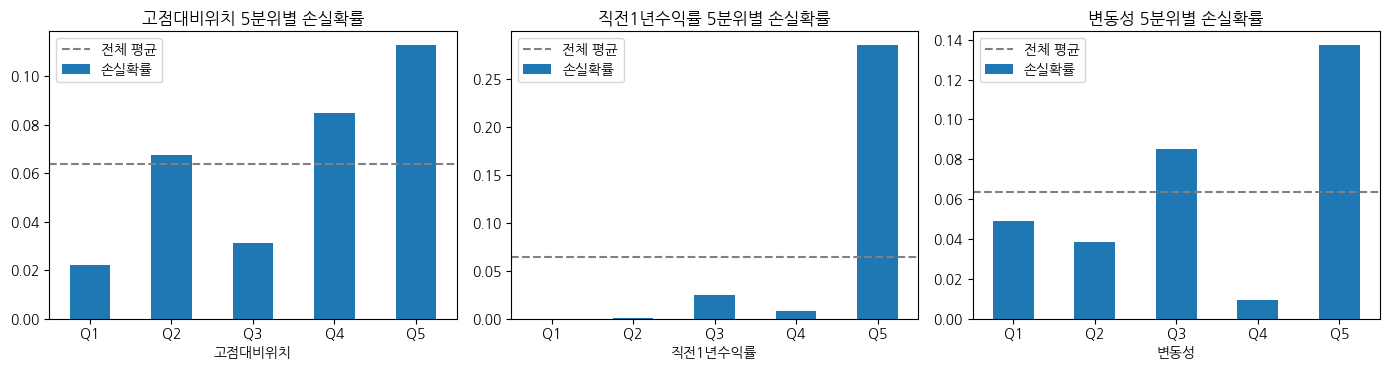


[고점대비위치]
        발행건수   구간평균   손실확률
고점대비위치                    
Q1       860  0.803  0.022
Q2       859  0.940  0.068
Q3       859  0.979  0.031
Q4       859  0.995  0.085
Q5       859  1.000  0.113

[직전1년수익률]
         발행건수   구간평균   손실확률
직전1년수익률                    
Q1        860 -0.121  0.000
Q2        859  0.063  0.001
Q3        859  0.145  0.024
Q4        859  0.213  0.008
Q5        859  0.528  0.285

[변동성]
     발행건수   구간평균   손실확률
변동성                    
Q1    860  0.154  0.049
Q2    859  0.196  0.038
Q3    859  0.235  0.085
Q4    859  0.287  0.009
Q5    859  0.489  0.137


In [23]:
# 신호 수준별 손실확률
def bucket_table(df, col, q=5):
    """신호를 5등분해서 구간별 손실확률 계산"""
    b = pd.qcut(df[col], q, labels=[f'Q{i}' for i in range(1, q + 1)])
    return df.groupby(b, observed=True).agg(
        발행건수=('손실', 'size'),
        구간평균=(col, 'mean'),
        손실확률=('손실', 'mean'),
    )

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
for ax, col in zip(axes, ['고점대비위치', '직전1년수익률', '변동성']):
    t = bucket_table(df, col)
    t['손실확률'].plot.bar(ax=ax, rot=0)
    ax.set_title(f'{col} 5분위별 손실확률')
    ax.axhline(df['손실'].mean(), ls='--', c='gray', label='전체 평균')
    ax.legend()
plt.tight_layout(); plt.show()

for col in ['고점대비위치', '직전1년수익률', '변동성']:
    print(f'\n[{col}]')
    print(bucket_table(df, col).round(3))

In [24]:
# 과열 구간의 시기별 구성
hot_cut = df['직전1년수익률'].quantile(0.8)        # Q5 경계값
hot = df[df['직전1년수익률'] >= hot_cut]

print(f'Q5 경계: 직전 1년 수익률 {hot_cut:.1%} 이상')
print(f"전체 손실 중 Q5가 차지하는 비율: {hot['손실'].sum() / df['손실'].sum():.1%}\n")

hot.groupby(hot['issue_date'].dt.year).agg(
    발행건수=('손실', 'size'),
    손실건수=('손실', 'sum'),
    손실확률=('손실', 'mean'),
).round(3)

Q5 경계: 직전 1년 수익률 26.0% 이상
전체 손실 중 Q5가 차지하는 비율: 89.4%



,발행건수,손실건수,손실확률
issue_date,,,
2007,197,112,0.569
2008,84,23,0.274
2009,81,0,0.000
2010,93,0,0.000
2011,2,0,0.000
2012,7,0,0.000
2013,52,0,0.000
2014,7,0,0.000
2015,67,0,0.000


In [25]:
# 과열 + 장기 고점 조합 신호
p = px[COMBOS[TARGET]]
pos3y = (p / p.rolling(756).max()).max(axis=1)     # 756거래일 = 3년 고점 대비 위치
df['3년고점대비'] = df['issue_date'].map(pos3y)

# 신호 A: 과열만 / 신호 B: 과열 + 3년 고점 근처
df['신호A_과열'] = df['직전1년수익률'] >= hot_cut
df['신호B_과열+고점'] = df['신호A_과열'] & (df['3년고점대비'] >= 0.95)

def evaluate(df, flag):
    on, off = df[df[flag]], df[~df[flag]]
    return pd.Series({
        '경보 발행건수': len(on),
        '경보 시 손실확률': on['손실'].mean(),
        '비경보 시 손실확률': off['손실'].mean(),
        '손실 포착률': on['손실'].sum() / df['손실'].sum(),
        '경보 비율(전체 중)': len(on) / len(df),
    })

pd.DataFrame({f: evaluate(df, f) for f in ['신호A_과열', '신호B_과열+고점']}).round(3)

,신호A_과열,신호B_과열+고점
경보 발행건수,860.000,552.000
경보 시 손실확률,0.285,0.333
비경보 시 손실확률,0.008,0.024
손실 포착률,0.894,0.672
경보 비율(전체 중),0.200,0.128


In [26]:
# 다른 조합에 같은 기준 적용
check = {}
for name in ['S&P+유로+니케이', 'KOSPI200+S&P+유로', 'S&P+유로 (2개)']:
    f = market_features(px, COMBOS[name])
    d = results[name].merge(f, left_on='issue_date', right_index=True, how='left').dropna()
    d['손실'] = (d['outcome'] == '손실').astype(int)
    d['경보'] = d['직전1년수익률'] >= hot_cut      # H지수 조합에서 정한 26% 기준 그대로
    check[name] = evaluate(d, '경보')

check[TARGET + ' (기준 만든 곳)'] = evaluate(df, '신호A_과열')
pd.DataFrame(check).round(3)

# S&P+유로+H지수 (기준 만든 곳), KOSPI200+S&P+유로 -＞ 통함
# S&P+유로+니케이, S&P+유로 (2개) -> 완전 실패

# 손실이 나는 방식이 2가지였을 가능성이 큼
# ① 거품 붕괴형: 특정 지수가 급등했다가 무너짐
# - 2007년 H지수, 2021년 H지수, 2007년 KOSPI(당시 중국 수혜로 급등)
# - 직전에 급등이 있었으니 과열 신호로 잡혀요 → H지수 조합, KOSPI200 조합에서 통한 이유

# ② 외부 충격형: 급등 없이 갑자기 터지는 위기
# - 2008년 금융위기 때 S&P, 유로스톡스, 니케이는 크게 오른 상태가 아니었는데 같이 폭락했어요
# - 직전 급등이 없으니 과열 신호가 원천적으로 못 잡아요 → 니케이 조합, 2개 조합에서 실패한 이유

,S&P+유로+니케이,KOSPI200+S&P+유로,S&P+유로 (2개),S&P+유로+H지수 (기준 만든 곳)
경보 발행건수,769.000,784.000,428.000,860.000
경보 시 손실확률,0.001,0.148,0.000,0.285
비경보 시 손실확률,0.067,0.005,0.035,0.008
손실 포착률,0.004,0.859,0.000,0.894
경보 비율(전체 중),0.179,0.182,0.100,0.200


In [27]:
# 가설 확인: 실패한 두 조합의 손실이 언제 발행된 ELS에서 났는지
for name in ['S&P+유로+니케이', 'S&P+유로 (2개)', 'KOSPI200+S&P+유로']:
    r = results[name]
    loss_years = r.loc[r['outcome'] == '손실', 'issue_date'].dt.year.value_counts().sort_index()
    print(f'[{name}] 손실 발행연도별 건수')
    print(loss_years.to_dict(), '\n')

# 2007년 각 지수의 직전 1년 수익률 (2007년 10월 기준)
t = pd.Timestamp('2007-10-31')
now = px.loc[:t].iloc[-1]                                 # 2007-10-31 직전 마지막 종가
before = px.loc[:t - pd.DateOffset(years=1)].iloc[-1]     # 1년 전 종가
print('2007-10 기준 직전 1년 수익률')
print((now / before - 1).round(3))

# H지수 조합: H지수가 과열 → 경보 울림 → H지수가 무너짐 → 원인을 정확히 잡음
# KOSPI200 조합: KOSPI200이 과열 → 경보 울림 → 그런데 손실은 S&P·유로가 무너져서 남 → 시기는 맞혔지만 원인은 다름
# 니케이 조합, 2개 조합: 과열된 지수가 없음 → 경보 안 울림 → S&P·유로가 무너짐 → 못 잡음

[S&P+유로+니케이] 손실 발행연도별 건수
{2007: 166, 2008: 71} 

[S&P+유로 (2개)] 손실 발행연도별 건수
{2007: 108, 2008: 26} 

[KOSPI200+S&P+유로] 손실 발행연도별 건수
{2007: 109, 2008: 26} 

2007-10 기준 직전 1년 수익률
KOSPI200    0.473
SPX         0.124
SX5E          NaN
NKY         0.021
HSCEI       1.683
dtype: float64


In [28]:
# 마무리(저장)
df.to_csv(f'{BASE}/output/02_q2_signal_HSCEI_combo.csv', index=False)
pd.DataFrame(check).round(4).to_csv(f'{BASE}/output/02_q2_signal_generalization.csv')
print('저장 완료')

저장 완료
